# Parte 4 — Inferência em mosaico

Imagens grandes são processadas em *tiles*; o
resultado final é o mosaico dos resultados de cada tile. Como há menos contexto
espacial na borda de cada tile, usa-se **tiles sobrepostos**, considera-se a
**parte interna** de cada um e faz-se a **média** dos resultados.

Isso é uma receita para **mapas densos** (probabilidade por pixel, distância):
média ponderada, pixel a pixel. Para **instâncias** não existe "média de
rótulos": cada tile decodifica os **seus** ids, e um objeto atravessado pela
linha que separa dois tiles vira **dois objetos** — um de cada lado. É essa
falha que esta parte mostra na prática, e depois corrige.

## Montagem

* **Mosaico:** 4×4 imagens de validação (128×128, o tamanho de treino) → uma
  imagem de **512×512** com ~700 núcleos. São 8 mosaicos (128 das 134 imagens de
  validação), com o **mesmo split das Partes 1 e 2** (`SEED=67`): nenhuma dessas
  imagens foi vista no treino.
* **Modelo:** a Trilha A da Parte 2 (fundo / interior / fronteira + distância,
  decodificada por watershed) sobre a U-Net, com a perda fixada na Parte 3
  (focal balanceada, γ=2). A espessura da fronteira e o tamanho mínimo de
  marcador foram recalibrados para a resolução de 128×128 (célula "teto do
  decodificador"). O treino salva um **checkpoint** em
  `results/4_trilha_a_unet.pt`; se ele existir, é carregado — o restante do
  notebook roda sem retreinar.
* **Tiles:** 128×128 (o tamanho de treino) com sobreposição de 32 px — 5×5 = 25
  tiles por mosaico.

## As quatro maneiras de obter instâncias no mosaico

| Nome | O que faz | Por que está aqui |
|---|---|---|
| **Sem tiles** (referência) | O mosaico inteiro num único *forward* (a U-Net é totalmente convolucional). | O teto: o que se perde ao dividir em tiles. |
| **Tiles ingênuo** | Watershed **em cada tile**; cada pixel fica com o rótulo do tile em que ele está mais interno; ids únicos por tile. | O slide 83 aplicado a rótulos de instância — item 2 do enunciado. |
| **Correção A — fusão por IoU** | Na **faixa de sobreposição** de cada par de tiles vizinhos, IoU entre as instâncias de um e do outro; IoU ≥ limiar → mesmo objeto (union-find). | A correção pedida no item 4: "fusão de instâncias entre tiles por IoU na faixa de sobreposição". |
| **Correção B — média dos mapas** | Média ponderada dos mapas **densos** (3 classes + distância) entre tiles, como manda o slide, e **um só** watershed global. | "O que a sua representação permitir": a Trilha A prevê mapas densos, então o slide 83 se aplica *antes* da decodificação. Não valeria para embeddings (Trilha B), que não são comparáveis entre tiles. |

**Regra de matching (todas as métricas de instância):** a mesma das Partes 1–3
— gulosa, por IoU decrescente (`src/nn/metrics.py`). A única diferença é
computacional: num mosaico com ~700 objetos, comparar cada par de máscaras
booleanas custa O(P·G·H·W) ≈ 10¹¹ operações; aqui o IoU sai de uma **matriz
calculada por histograma 2D** (`label_map_iou_matrix`, O(H·W)) e as mesmas
regras são aplicadas sobre a matriz. A célula de sanidade abaixo confere que os
dois caminhos dão o mesmo número.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split
from scipy import ndimage

from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform

from src.nn.models import TrilhaAModel
from src.nn.optimizers import create_optimizer

from src.nn.loss import cross_entropy, balanced_cross_entropy, focal_loss, l1_loss

from src.nn.targets import instance_map_to_boundary_targets, decode_watershed

from src.nn.metrics import (
    instance_scores,
    count_tp_fp_fn,
    mean_average_precision,
    binary_iou_dice,
    label_map_iou_matrix,
    instance_scores_from_map,
    greedy_match_from_iou,
    count_tp_fp_fn_from_iou,
    mean_average_precision_from_iou,
)

from src.nn.tiling import (
    tile_grid,
    predict_tiles,
    stitch_maps,
    stitch_instances_naive,
    fuse_instances,
    compact_labels,
    cut_lines,
)

In [2]:
# ============================================================
# CONFIGURACOES
# ============================================================

SEED = 67                      # mesmo split treino/validacao das Partes 1 e 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# Modelo: Trilha A (Parte 2) com a perda fixada na Parte 3
# ------------------------------------------------------------

IMAGE_SIZE      = (128, 128)
BACKBONE        = "unet"
MIN_INST_PIXELS = 4
LOSS_CFG        = dict(kind="focal", gamma=2.0, balanced=True)
DISTANCE_WEIGHT = 1.0
NUM_EPOCHS      = 10
BATCH_SIZE      = 16

# Espessura da fronteira e tamanho minimo de marcador recalibrados para a
# resolucao de 128x128 (diametro mediano dos nucleos ~5 px): com os valores
# da Parte 3 (2 e 5) mais da metade dos nucleos nao tem interior de 5 px nem
# no GT -- ver a celula "teto do decodificador" abaixo.
BOUNDARY_WIDTH  = 1
INTERIOR_THRESH = 0.50         # prob minima da classe interior p/ virar marcador
MIN_MARKER_SIZE = 2            # marcadores menores que isso sao ruido

# ------------------------------------------------------------
# Mosaico
# ------------------------------------------------------------

GRID      = (4, 4)             # 4x4 imagens de 128x128 -> 512x512
N_MOSAICS = 8                  # 8 x 16 = 128 das 134 imagens de validacao

# ------------------------------------------------------------
# Tiles
# ------------------------------------------------------------

TILE          = 128            # tamanho de treino
OVERLAP       = 32             # sobreposicao entre tiles vizinhos (px)
FUSE_IOU      = 0.5            # IoU minimo, na faixa de sobreposicao, p/ fundir
OVERLAP_SWEEP = [8, 16, 32, 64, 96]
FUSE_IOU_SWEEP = [0.10, 0.25, 0.50, 0.75]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
CHECKPOINT = os.path.join(RESULTS_DIR, "4_trilha_a_unet.pt")

METHODS = {
    "referencia":    "Sem tiles (referencia)",
    "tiles_ingenuo": "Tiles ingenuo",
    "fusao_iou":     "Correcao A: fusao por IoU",
    "media_mapas":   "Correcao B: media dos mapas",
}
METHOD_COLORS = {
    "referencia": "#7f7f7f", "tiles_ingenuo": "#c44e52",
    "fusao_iou": "#4c72b0", "media_mapas": "#55a868",
}

Device: cpu


## Alvos, treino e decodificação (os mesmos da Parte 2/3)

In [3]:
# ============================================================
# ALVOS + PERDA + TREINO  (copiados da Parte 3, sem mudancas)
# ============================================================

def build_targets(instance_map_batch):
    sem, dist = [], []
    for i in range(instance_map_batch.shape[0]):
        s, d = instance_map_to_boundary_targets(
            instance_map_batch[i].detach().cpu().numpy(),
            boundary_width=BOUNDARY_WIDTH,
            min_pixels=MIN_INST_PIXELS,
        )
        sem.append(s)
        dist.append(d)
    return torch.stack(sem), torch.stack(dist)


def make_semantic_loss(loss_cfg):
    kind = loss_cfg["kind"]
    if kind == "ce":
        return lambda pred, target: cross_entropy(pred, target)
    if kind == "balanced_ce":
        return lambda pred, target: balanced_cross_entropy(pred, target)
    if kind == "focal":
        gamma = loss_cfg["gamma"]
        class_weights = "balanced" if loss_cfg["balanced"] else None
        return lambda pred, target: focal_loss(pred, target, class_weights=class_weights, gamma=gamma)
    raise ValueError(f"loss_cfg desconhecido: {loss_cfg}")


def train_epoch(dataloader, model, optimizer, device, semantic_loss_fn):

    model.train()
    acc = {"loss": 0.0, "semantic": 0.0, "distance": 0.0}

    for X, instance_map in dataloader:

        X = X.to(device)
        sem_t, dist_t = build_targets(instance_map)
        sem_t, dist_t = sem_t.to(device), dist_t.to(device)

        sem_logits, dist_logits = model(X)
        dist_pred = torch.sigmoid(dist_logits).squeeze(1)

        sem_loss  = semantic_loss_fn(sem_logits, sem_t)
        dist_loss = l1_loss(dist_pred, dist_t)

        loss = sem_loss + DISTANCE_WEIGHT * dist_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        acc["loss"]     += loss.item()
        acc["semantic"] += sem_loss.item()
        acc["distance"] += dist_loss.item()

    n = len(dataloader)
    return {k: v / n for k, v in acc.items()}


# ============================================================
# DECODIFICACAO  (a mesma da Parte 2)
# ============================================================

def semantic_from_outputs(sem_prob):
    # foreground = interior + fronteira (tudo que nao e fundo)
    fg_prob = sem_prob[1] + sem_prob[2]
    fg_mask = sem_prob.argmax(axis=0) != 0
    return fg_prob, fg_mask


def watershed_from_outputs(sem_prob, dist_pred):
    interior_mask   = sem_prob[1] > INTERIOR_THRESH
    foreground_mask = sem_prob.argmax(axis=0) != 0
    return decode_watershed(
        interior_mask=interior_mask,
        foreground_mask=foreground_mask,
        landscape=-dist_pred,
        min_marker_size=MIN_MARKER_SIZE,
    )


def masks_to_list(instance_map):
    ids = np.unique(instance_map)
    ids = ids[ids > 0]
    return [instance_map == i for i in ids]


@torch.no_grad()
def forward_fn(batch):
    # Interface usada por predict_tiles: batch [B,3,t,t] -> (sem_prob [B,3,t,t], dist [B,t,t])
    sem_logits, dist_logits = model(batch.to(device))
    return (
        torch.softmax(sem_logits, dim=1).cpu().numpy(),
        torch.sigmoid(dist_logits).squeeze(1).cpu().numpy(),
    )

In [4]:
# ============================================================
# DADOS  --  MESMO SPLIT DAS PARTES 1 E 2
# ============================================================

train_transform = SegmentationTransform(size=IMAGE_SIZE, augment=True)
eval_transform  = SegmentationTransform(size=IMAGE_SIZE, augment=False)

train_dataset_full = BBBC038Dataset(root="../data/stage1_train", transform=train_transform, mode="instance")
eval_dataset_full  = BBBC038Dataset(root="../data/stage1_train", transform=eval_transform,  mode="instance")

n_total = len(train_dataset_full)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

train_split, _ = random_split(train_dataset_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
_, val_split   = random_split(eval_dataset_full,  [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

print(f"treino: {len(train_split)}  |  validacao: {len(val_split)}")

train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
eval_loader  = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

treino: 536  |  validacao: 134


## Teto do decodificador

O watershed só recupera um núcleo se ele tiver um **marcador**: um componente
conexo da classe *interior* com pelo menos `MIN_MARKER_SIZE` pixels. A 128×128
os núcleos são pequenos (diâmetro mediano ~5 px), então a espessura da fronteira
decide quantos deles ainda têm interior. A célula abaixo mede isso **no próprio
GT** (previsão perfeita): é o teto de recall que nenhum treino ultrapassa.

In [5]:
def decoder_ceiling(dataset_split, boundary_width, min_marker_size):
    # fracao dos nucleos do GT cujo alvo "interior" tem >= min_marker_size px
    survived, total = 0, 0
    for i in range(len(dataset_split)):
        _, inst = dataset_split[i]
        inst = inst.numpy()
        sem, _ = instance_map_to_boundary_targets(inst, boundary_width=boundary_width, min_pixels=MIN_INST_PIXELS)
        sem = sem.numpy()
        ids = np.unique(inst); ids = ids[ids > 0]
        interior_px = ndimage.sum((sem == 1), labels=inst, index=ids)
        survived += int(np.sum(np.asarray(interior_px) >= min_marker_size))
        total += len(ids)
    return survived / total

for label, bw, mm in [("Parte 3  (BOUNDARY_WIDTH=2, MIN_MARKER_SIZE=5)", 2, 5),
                      ("Parte 4  (BOUNDARY_WIDTH=%d, MIN_MARKER_SIZE=%d)" % (BOUNDARY_WIDTH, MIN_MARKER_SIZE), BOUNDARY_WIDTH, MIN_MARKER_SIZE)]:
    print(f"{label}: {100 * decoder_ceiling(val_split, bw, mm):.1f}% dos nucleos de validacao ainda tem marcador no GT")

Parte 3  (BOUNDARY_WIDTH=2, MIN_MARKER_SIZE=5): 47.2% dos nucleos de validacao ainda tem marcador no GT
Parte 4  (BOUNDARY_WIDTH=1, MIN_MARKER_SIZE=2): 87.8% dos nucleos de validacao ainda tem marcador no GT


## Modelo: treina uma vez, depois carrega o checkpoint

O checkpoint guarda os pesos, a curva de treino e a configuração. É o
"checkpoint do modelo final" dos entregáveis, e o que o `inferencia.ipynb`
pode carregar (`src.nn.models.TrilhaAModel`) para rodar sem retreinar.

checkpoint carregado: results\4_trilha_a_unet.pt
config do treino salvo: {"backbone": "unet", "loss": {"kind": "focal", "gamma": 2.0, "balanced": true}, "boundary_width": 1, "min_inst_pixels": 4, "distance_weight": 1.0, "epochs": 10, "batch_size": 16, "image_size": [128, 128], "split_seed": 67, "interior_thresh": 0.5, "min_marker_size": 2}


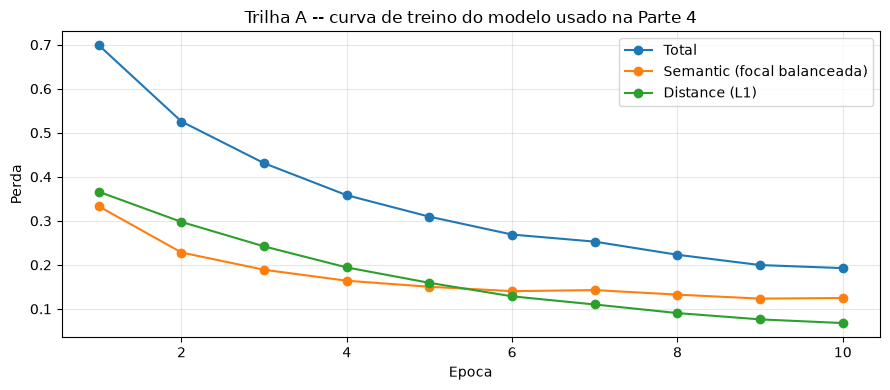

In [6]:
# ============================================================
# TREINO  (ou carga do checkpoint, se ja existir)
# ============================================================

model = TrilhaAModel(BACKBONE).to(device)

train_config = {
    "backbone": BACKBONE, "loss": LOSS_CFG, "boundary_width": BOUNDARY_WIDTH,
    "min_inst_pixels": MIN_INST_PIXELS, "distance_weight": DISTANCE_WEIGHT,
    "epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE, "image_size": list(IMAGE_SIZE),
    "split_seed": SEED, "interior_thresh": INTERIOR_THRESH, "min_marker_size": MIN_MARKER_SIZE,
}

if os.path.exists(CHECKPOINT):

    ckpt = torch.load(CHECKPOINT, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    history = ckpt.get("history", [])

    print(f"checkpoint carregado: {CHECKPOINT}")
    print("config do treino salvo:", json.dumps(ckpt["config"]))

    if ckpt["config"] != train_config:
        print("\nATENCAO: a configuracao acima difere da deste notebook. "
              "Apague o checkpoint para retreinar com a configuracao atual.")

else:

    optimizer = create_optimizer("Adam", model, lr=1e-3)
    semantic_loss_fn = make_semantic_loss(LOSS_CFG)

    history = []
    t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        logs = train_epoch(train_loader, model, optimizer, device, semantic_loss_fn)
        history.append(logs)
        print(
            f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | loss {logs['loss']:.4f} | "
            f"semantic ({LOSS_CFG['kind']}) {logs['semantic']:.4f} | distance (L1) {logs['distance']:.4f}"
        )

    print(f"\ntreino: {(time.time() - t0) / 60:.1f} min")

    torch.save(
        {"state_dict": model.state_dict(), "history": history, "config": train_config},
        CHECKPOINT,
    )
    print(f"checkpoint salvo em {CHECKPOINT}")

model.eval()

if history:
    ep = np.arange(1, len(history) + 1)
    plt.figure(figsize=(9, 4))
    for key, label in [("loss", "Total"), ("semantic", "Semantic (focal balanceada)"), ("distance", "Distance (L1)")]:
        plt.plot(ep, [h[key] for h in history], marker="o", label=label)
    plt.xlabel("Epoca"); plt.ylabel("Perda"); plt.title("Trilha A -- curva de treino do modelo usado na Parte 4")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Sanidade: métricas por matriz de IoU ≡ métricas por listas de máscaras

Antes de confiar nos números do mosaico, conferimos num batch de validação que
`mean_average_precision_from_iou` / `count_tp_fp_fn_from_iou` (usadas aqui)
reproduzem exatamente `mean_average_precision` / `count_tp_fp_fn` (usadas nas
Partes 1–3). Mesma regra de matching; só o cálculo do IoU mudou.

In [7]:
Xb, Yb = next(iter(eval_loader))
sem_prob_b, dist_pred_b = forward_fn(Xb)

preds_list, gts_list, scores_list = [], [], []
ious_check, scores_map = [], []

for i in range(Xb.shape[0]):

    fg_prob, _ = semantic_from_outputs(sem_prob_b[i])
    lab = compact_labels(watershed_from_outputs(sem_prob_b[i], dist_pred_b[i]))
    gt  = compact_labels(Yb[i].numpy())

    # caminho das Partes 1-3: listas de mascaras
    p_masks, g_masks = masks_to_list(lab), masks_to_list(gt)
    preds_list.append(p_masks); gts_list.append(g_masks)
    scores_list.append(instance_scores(fg_prob, p_masks))

    # caminho da Parte 4: matriz de IoU
    ious_check.append(label_map_iou_matrix(lab, gt))
    scores_map.append(instance_scores_from_map(fg_prob, lab))

map_masks, aps_masks = mean_average_precision(preds_list, gts_list, scores_list)
map_iou,   aps_iou   = mean_average_precision_from_iou(ious_check, scores_map)
tpfpfn_masks = count_tp_fp_fn(preds_list, gts_list, 0.50)
tpfpfn_iou   = count_tp_fp_fn_from_iou(ious_check, 0.50)

print(f"mAP@[.50:.95]  listas de mascaras: {map_masks:.6f} | matriz de IoU: {map_iou:.6f}")
print(f"TP/FP/FN@0.50  listas de mascaras: {tpfpfn_masks} | matriz de IoU: {tpfpfn_iou}")

assert np.isclose(map_masks, map_iou), "mAP diverge entre os dois caminhos"
assert all(np.isclose(aps_masks[k], aps_iou[k]) for k in aps_masks), "AP por limiar diverge"
assert tpfpfn_masks == tpfpfn_iou, "TP/FP/FN divergem"
print("\nOK: os dois caminhos dao os mesmos numeros.")

mAP@[.50:.95]  listas de mascaras: 0.129198 | matriz de IoU: 0.129198
TP/FP/FN@0.50  listas de mascaras: (449, 187, 481) | matriz de IoU: (449, 187, 481)

OK: os dois caminhos dao os mesmos numeros.


## Mosaicos

Cada mosaico é um grid 4×4 de imagens de validação (na resolução de treino,
128×128), com o ground truth de instâncias colado com ids únicos. As emendas
entre imagens fazem parte do cenário (é assim que uma lâmina grande com várias
regiões se parece); o que importa é que **as linhas de corte dos tiles não
coincidem com as emendas**: com tiles de 128 e passo 96, as linhas de corte
caem em x, y ∈ {112, 208, 304, 400} — no meio das imagens, atravessando núcleos.

8 mosaicos de 512x512 | objetos por mosaico: [700, 746, 678, 669, 620, 874, 869, 678] | total 5834
diametro equivalente dos objetos (px): mediana 5.8 | p90 11.6 | max 32.3
tiles de 128 com sobreposicao 32: 25 tiles por mosaico (5x5)


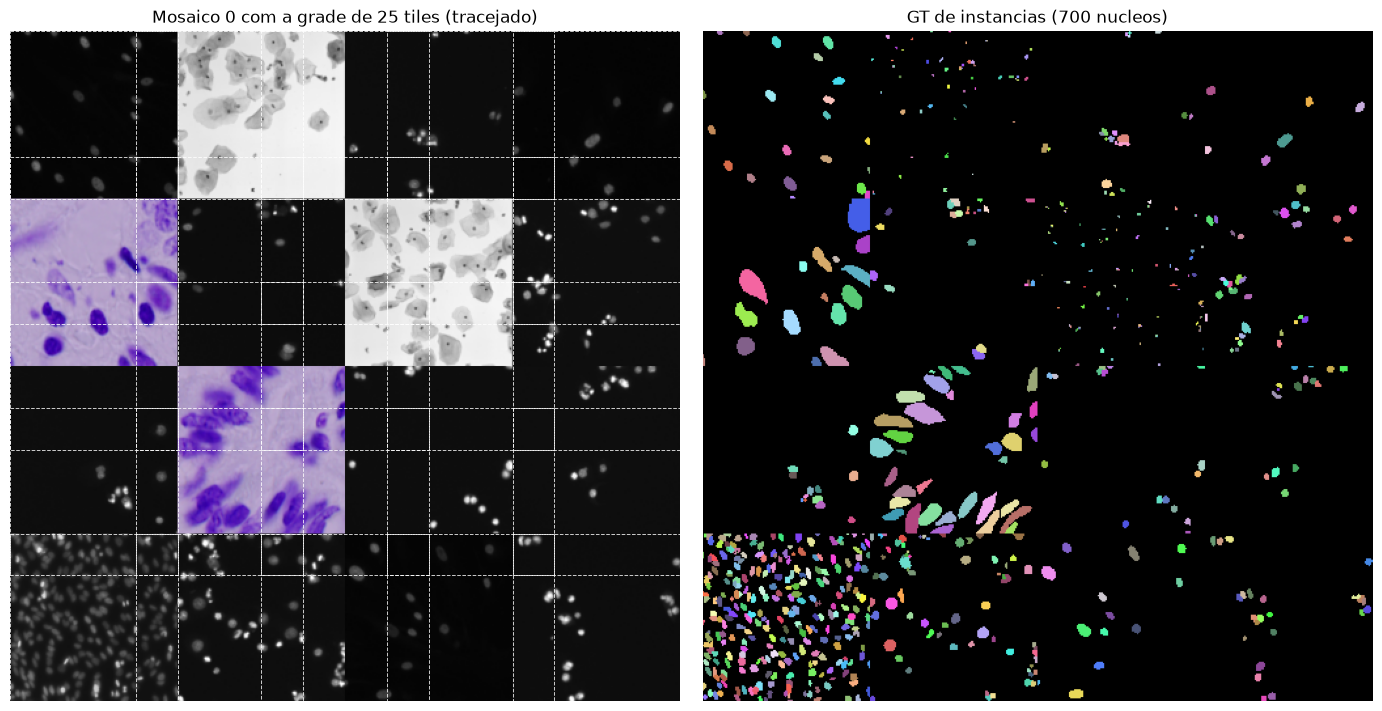

In [8]:
# ============================================================
# MONTAGEM DOS MOSAICOS
# ============================================================

def build_mosaics(dataset_split, grid, n_mosaics, seed):
    rows, cols = grid
    per_mosaic = rows * cols

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(dataset_split))

    mosaics = []

    for m in range(n_mosaics):

        idx = order[m * per_mosaic:(m + 1) * per_mosaic]

        H, W = rows * IMAGE_SIZE[0], cols * IMAGE_SIZE[1]
        image = torch.zeros(3, H, W)
        gt = np.zeros((H, W), dtype=np.int32)
        next_id = 0

        for k, i in enumerate(idx):

            r, c = divmod(k, cols)
            img, inst = dataset_split[int(i)]
            inst = compact_labels(inst.numpy())

            y0, x0 = r * IMAGE_SIZE[0], c * IMAGE_SIZE[1]
            image[:, y0:y0 + IMAGE_SIZE[0], x0:x0 + IMAGE_SIZE[1]] = img
            gt[y0:y0 + IMAGE_SIZE[0], x0:x0 + IMAGE_SIZE[1]] = np.where(inst > 0, inst + next_id, 0)
            next_id += int(inst.max())

        mosaics.append({"image": image, "gt": gt, "indices": [int(i) for i in idx]})

    return mosaics


def colorize(label_map, seed=0):
    # cores aleatorias por id: vizinhos com ids consecutivos ficam distinguiveis
    n = int(label_map.max())
    rng = np.random.default_rng(seed)
    lut = rng.uniform(0.25, 1.0, size=(n + 1, 3)).astype(np.float32)
    lut[0] = 0.0
    return lut[label_map]


def draw_tile_grid(ax, windows, color="white"):
    for (y0, x0, y1, x1) in windows:
        ax.add_patch(patches.Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0,
                                       fill=False, edgecolor=color, linestyle="--", linewidth=0.7, alpha=0.8))


mosaics = build_mosaics(val_split, GRID, N_MOSAICS, SEED)
gts = [m["gt"] for m in mosaics]

MOSAIC_H, MOSAIC_W = gts[0].shape
windows_main = tile_grid(MOSAIC_H, MOSAIC_W, TILE, TILE - OVERLAP)

n_objects = [int(g.max()) for g in gts]
areas = np.concatenate([np.bincount(g.ravel())[1:] for g in gts])
diameters = 2 * np.sqrt(areas / np.pi)

print(f"{len(mosaics)} mosaicos de {MOSAIC_H}x{MOSAIC_W} | objetos por mosaico: {n_objects} | total {sum(n_objects)}")
print(f"diametro equivalente dos objetos (px): mediana {np.median(diameters):.1f} | "
      f"p90 {np.percentile(diameters, 90):.1f} | max {diameters.max():.1f}")
print(f"tiles de {TILE} com sobreposicao {OVERLAP}: {len(windows_main)} tiles por mosaico "
      f"({int(np.sqrt(len(windows_main)))}x{int(np.sqrt(len(windows_main)))})")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(mosaics[0]["image"].permute(1, 2, 0).numpy())
draw_tile_grid(ax[0], windows_main)
ax[0].set_title(f"Mosaico 0 com a grade de {len(windows_main)} tiles (tracejado)")
ax[1].imshow(colorize(gts[0]))
ax[1].set_title(f"GT de instancias ({n_objects[0]} nucleos)")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

## As quatro pipelines

`run_pipelines` roda **um** forward por tile e deriva as três variantes em
tiles a partir das mesmas saídas — o ingênuo, a Correção A e a Correção B
compartilham exatamente as mesmas previsões por tile; só muda o que se faz com
elas. A referência sem tiles é um forward do mosaico inteiro.

A margem penalizada de cada tile é metade da sobreposição (`OVERLAP // 2`): na
faixa em que dois tiles se sobrepõem, cada pixel pertence ao tile em que está
mais interno, e o peso da média cai linearmente até a borda.

In [9]:
# ============================================================
# PIPELINES
# ============================================================

def run_pipelines(image, tile, overlap, fuse_iou, full_outputs=None):
    '''
    Devolve os quatro mapas de instancias do mosaico + o que e preciso
    para as figuras e para reavaliar a fusao com outro limiar.
    '''

    H, W = image.shape[-2:]
    windows = tile_grid(H, W, tile, tile - overlap)
    margin = overlap // 2

    # -------- 1. referencia: mosaico inteiro num forward --------
    if full_outputs is None:
        sem_full, dist_full = forward_fn(image[None])
        full_outputs = (sem_full[0], dist_full[0])
    sem_full, dist_full = full_outputs
    ref_map = compact_labels(watershed_from_outputs(sem_full, dist_full))

    # -------- forward por tile (compartilhado por 2, 3 e 4) --------
    tile_outputs = predict_tiles(forward_fn, image, windows)

    # -------- 2. tiles ingenuo: watershed por tile + colagem --------
    tile_labels = [watershed_from_outputs(s, d) for (s, d) in tile_outputs]
    naive_raw, offsets, owner = stitch_instances_naive(tile_labels, windows, (H, W), margin)
    naive_map = compact_labels(naive_raw)

    # -------- 3. correcao A: fusao por IoU na faixa de sobreposicao --------
    fused_map, n_merges = fuse_instances(tile_labels, windows, offsets, naive_raw, iou_threshold=fuse_iou)

    # -------- 4. correcao B: media dos mapas densos + watershed global --------
    sem_avg, dist_avg = stitch_maps(tile_outputs, windows, (H, W), margin)
    avg_map = compact_labels(watershed_from_outputs(sem_avg, dist_avg))

    fg_ref, _ = semantic_from_outputs(sem_full)
    fg_avg, _ = semantic_from_outputs(sem_avg)

    return {
        "maps": {"referencia": ref_map, "tiles_ingenuo": naive_map,
                 "fusao_iou": fused_map, "media_mapas": avg_map},
        # score de cada instancia = prob. media de nao-fundo dentro dela; as
        # tres variantes em tiles usam o mesmo mapa medio de probabilidade
        "fg_prob": {"referencia": fg_ref, "tiles_ingenuo": fg_avg,
                    "fusao_iou": fg_avg, "media_mapas": fg_avg},
        "owner": owner, "windows": windows, "n_merges": n_merges,
        "full_outputs": full_outputs,
        "_tile_labels": tile_labels, "_offsets": offsets, "_naive_raw": naive_raw,
    }


def evaluate_runs(runs, gts, methods=METHODS):
    per_method = {}

    for method in methods:

        maps = [r["maps"][method] for r in runs]
        ious = [label_map_iou_matrix(m, gt) for m, gt in zip(maps, gts)]
        scores = [instance_scores_from_map(r["fg_prob"][method], m) for r, m in zip(runs, maps)]

        map_value, aps = mean_average_precision_from_iou(ious, scores)
        tp50, fp50, fn50 = count_tp_fp_fn_from_iou(ious, 0.50)

        sem = [binary_iou_dice(m > 0, gt > 0) for m, gt in zip(maps, gts)]

        per_method[method] = {
            "IoU (semantico)":        float(np.mean([s[0] for s in sem])),
            "Dice (semantico)":       float(np.mean([s[1] for s in sem])),
            "mAP@[.50:.95]":          float(map_value),
            "AP@0.50":                float(aps[0.5]),
            "AP@0.75":                float(aps[0.75]),
            "AP@0.90":                float(aps[0.9]),
            "TP@0.50":                int(tp50),
            "FP@0.50":                int(fp50),
            "FN@0.50":                int(fn50),
            "instancias previstas":   int(sum(iou.shape[0] for iou in ious)),
            "erro medio de contagem": float(np.mean([abs(iou.shape[0] - iou.shape[1]) for iou in ious])),
            "_aps": aps, "_ious": ious,
        }

    return per_method


t0 = time.time()
runs = [run_pipelines(m["image"], TILE, OVERLAP, FUSE_IOU) for m in mosaics]
print(f"{len(runs)} mosaicos x 4 pipelines em {time.time() - t0:.1f}s")
print("fusoes efetuadas por mosaico (Correcao A):", [r["n_merges"] for r in runs])

results = evaluate_runs(runs, gts)

8 mosaicos x 4 pipelines em 7.4s
fusoes efetuadas por mosaico (Correcao A): [300, 337, 362, 298, 336, 459, 336, 392]


In [10]:
# ============================================================
# METRICAS  --  mAP antes e depois da correcao (item 4)
# ============================================================
#
# "erro medio de contagem" e por MOSAICO (16 imagens); divida por 16 para
# comparar com o erro por imagem das Partes 1-3.
# ============================================================

table_rows = [k for k in results["referencia"] if not k.startswith("_")]
comparison = pd.DataFrame(
    {METHODS[m]: {k: results[m][k] for k in table_rows} for m in METHODS}
)

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
comparison

,Sem tiles (referencia),Tiles ingenuo,Correcao A: fusao por IoU,Correcao B: media dos mapas
IoU (semantico),0.5610,0.5608,0.5608,0.5651
Dice (semantico),0.7179,0.7177,0.7177,0.7213
mAP@[.50:.95],0.1362,0.1177,0.1383,0.1378
AP@0.50,0.4088,0.3726,0.4137,0.4138
AP@0.75,0.0399,0.0304,0.0410,0.0399
AP@0.90,0.0001,0.0001,0.0001,0.0001
TP@0.50,3089.0000,3050.0000,3088.0000,3102.0000
FP@0.50,1465.0000,2264.0000,1480.0000,1433.0000
FN@0.50,2745.0000,2784.0000,2746.0000,2732.0000
instancias previstas,4554.0000,5314.0000,4568.0000,4535.0000


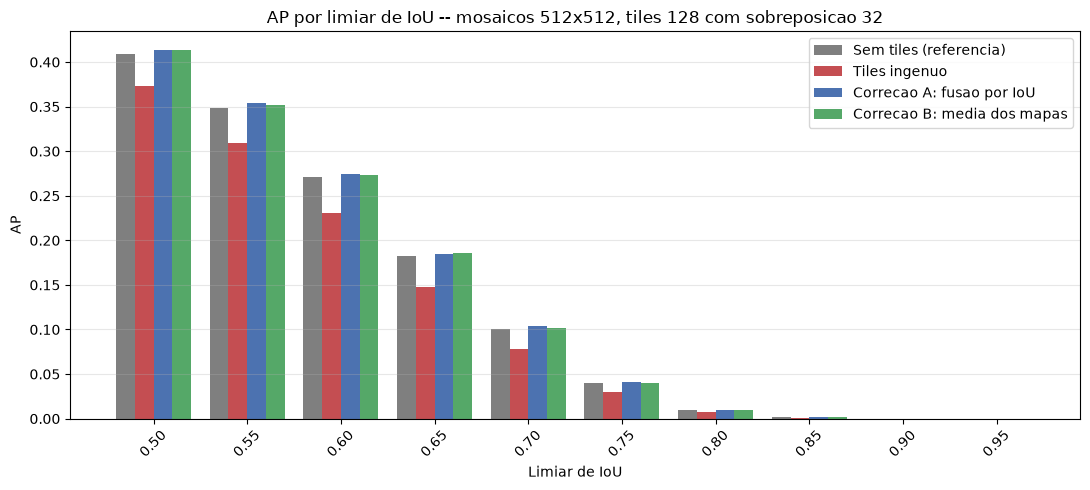

In [11]:
# ============================================================
# AP  x  LIMIAR DE IoU  --  as quatro pipelines lado a lado
# ============================================================

thresholds = np.array(sorted(results["referencia"]["_aps"]))
bar_w = 0.01                                   # 4 barras por limiar (limiares a cada 0.05)

plt.figure(figsize=(11, 5))
for k, method in enumerate(METHODS):
    plt.bar(
        thresholds + (k - 1.5) * bar_w, [results[method]["_aps"][t] for t in thresholds],
        width=bar_w, label=METHODS[method], color=METHOD_COLORS[method],
    )
plt.xlabel("Limiar de IoU"); plt.ylabel("AP")
plt.title(f"AP por limiar de IoU -- mosaicos {MOSAIC_H}x{MOSAIC_W}, tiles {TILE} com sobreposicao {OVERLAP}")
plt.xticks(thresholds, [f"{t:.2f}" for t in thresholds], rotation=45)
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## O que acontece com um objeto na fronteira entre dois tiles (item 3)

Na colagem ingênua, a **linha de corte** é onde a posse do pixel passa de um
tile para o vizinho (no meio da faixa de sobreposição). Um núcleo atravessado
por ela recebe um id do tile da esquerda e outro do da direita — **um objeto,
duas instâncias**. Os dois tiles enxergam o núcleo inteiro (ele está dentro da
faixa de sobreposição de 32 px, maior que a mediana de diâmetro), então a
informação para juntá-los existe; a colagem por rótulos é que a joga fora.

Primeiro o mosaico inteiro; depois um zoom num núcleo partido, com a decodificação
de cada tile vizinho separadamente.

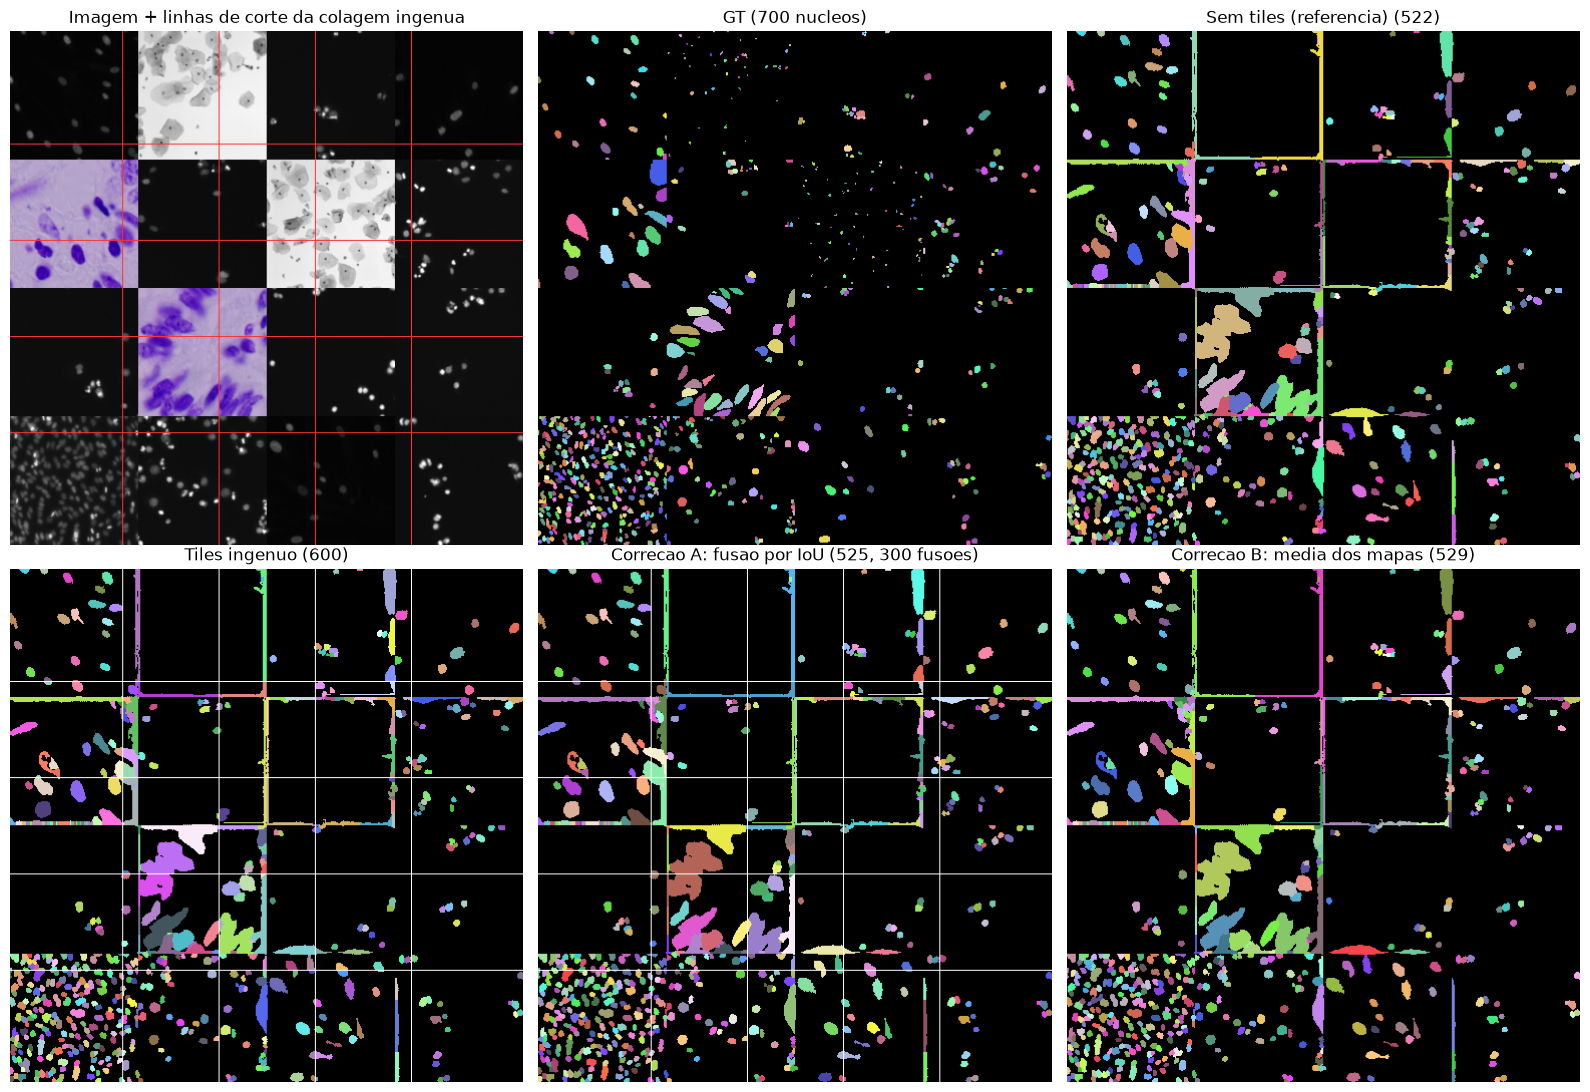

In [12]:
# ============================================================
# MOSAICO INTEIRO  --  linhas de corte sobre as instancias
# ============================================================

def overlay_lines(rgb, lines, color=(1.0, 1.0, 1.0)):
    out = np.array(rgb, dtype=np.float32, copy=True)
    out[lines] = color
    return out


M = 0
run, gt = runs[M], gts[M]
lines = cut_lines(run["owner"])
image_rgb = mosaics[M]["image"].permute(1, 2, 0).numpy()

fig, ax = plt.subplots(2, 3, figsize=(16, 11))
ax[0, 0].imshow(overlay_lines(image_rgb, lines, (1, 0.2, 0.2)))
ax[0, 0].set_title("Imagem + linhas de corte da colagem ingenua")
ax[0, 1].imshow(colorize(gt));                     ax[0, 1].set_title(f"GT ({int(gt.max())} nucleos)")
ax[0, 2].imshow(colorize(run["maps"]["referencia"]))
ax[0, 2].set_title(f"{METHODS['referencia']} ({int(run['maps']['referencia'].max())})")
ax[1, 0].imshow(overlay_lines(colorize(run["maps"]["tiles_ingenuo"]), lines))
ax[1, 0].set_title(f"{METHODS['tiles_ingenuo']} ({int(run['maps']['tiles_ingenuo'].max())})")
ax[1, 1].imshow(overlay_lines(colorize(run["maps"]["fusao_iou"]), lines))
ax[1, 1].set_title(f"{METHODS['fusao_iou']} ({int(run['maps']['fusao_iou'].max())}, {run['n_merges']} fusoes)")
ax[1, 2].imshow(colorize(run["maps"]["media_mapas"]))
ax[1, 2].set_title(f"{METHODS['media_mapas']} ({int(run['maps']['media_mapas'].max())})")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout(); plt.show()

mosaico 1, objeto GT #170: 398 px, diametro ~23 px
  tiles que reivindicam o objeto: [2, 3]
  Sem tiles (referencia)          : 2 instancia(s) sobre o objeto
  Tiles ingenuo                   : 3 instancia(s) sobre o objeto
  Correcao A: fusao por IoU       : 2 instancia(s) sobre o objeto
  Correcao B: media dos mapas     : 2 instancia(s) sobre o objeto


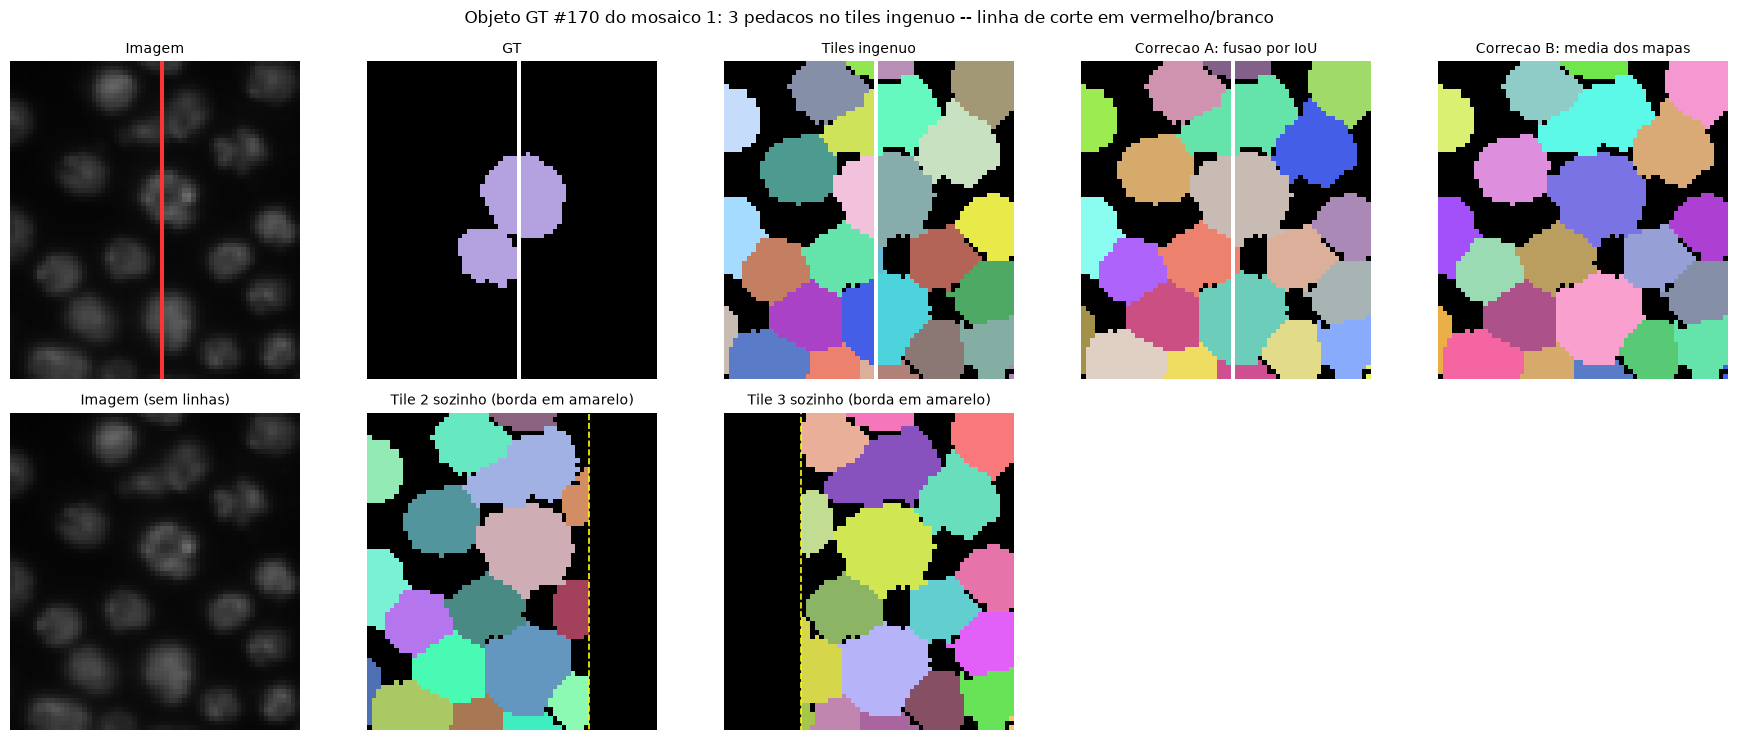

In [13]:
# ============================================================
# ZOOM  --  um nucleo partido pela linha de corte
# ============================================================

def objects_on_cut(gt_map, owner):
    # id de GT esta "na linha de corte" se seus pixels pertencem a mais de um tile
    n = int(gt_map.max())
    if n == 0:
        return np.zeros(0, dtype=bool)
    n_owners = ndimage.labeled_comprehension(
        owner, gt_map, np.arange(1, n + 1), lambda v: len(np.unique(v)), int, 0
    )
    return np.asarray(n_owners) > 1


def pieces(pred_map, gt_map, gt_id, min_frac=0.20):
    # ids previstos que cobrem pelo menos min_frac da area do objeto
    obj = gt_map == gt_id
    ids, counts = np.unique(pred_map[obj], return_counts=True)
    keep = (ids > 0) & (counts >= min_frac * obj.sum())
    return ids[keep].tolist()


# escolhe, entre todos os mosaicos, o objeto na linha de corte mais partido pelo ingenuo
best = None
for m, (run, gt) in enumerate(zip(runs, gts)):
    on_cut = objects_on_cut(gt, run["owner"])
    area = np.bincount(gt.ravel())
    for gt_id in np.flatnonzero(on_cut) + 1:
        n_pieces = len(pieces(run["maps"]["tiles_ingenuo"], gt, gt_id))
        key = (n_pieces, area[gt_id])
        if n_pieces >= 2 and (best is None or key > best[0]):
            best = (key, m, int(gt_id))

(n_pieces, _), M, GT_ID = best
run, gt = runs[M], gts[M]
obj = gt == GT_ID
ys, xs = np.nonzero(obj)
PAD = 20
y0, y1 = max(0, ys.min() - PAD), min(MOSAIC_H, ys.max() + PAD + 1)
x0, x1 = max(0, xs.min() - PAD), min(MOSAIC_W, xs.max() + PAD + 1)
crop = (slice(y0, y1), slice(x0, x1))

lines = cut_lines(run["owner"])
image_rgb = mosaics[M]["image"].permute(1, 2, 0).numpy()
owners = sorted(np.unique(run["owner"][obj]).tolist())

print(f"mosaico {M}, objeto GT #{GT_ID}: {obj.sum()} px, diametro ~{2 * np.sqrt(obj.sum() / np.pi):.0f} px")
print(f"  tiles que reivindicam o objeto: {owners}")
for method in METHODS:
    print(f"  {METHODS[method]:32s}: {len(pieces(run['maps'][method], gt, GT_ID))} instancia(s) sobre o objeto")

fig, ax = plt.subplots(2, 5, figsize=(18, 7.5))

panels = [
    ("Imagem", overlay_lines(image_rgb, lines, (1, 0.2, 0.2))),
    ("GT", overlay_lines(colorize(gt * obj), lines)),
    (METHODS["tiles_ingenuo"], overlay_lines(colorize(run["maps"]["tiles_ingenuo"]), lines)),
    (METHODS["fusao_iou"], overlay_lines(colorize(run["maps"]["fusao_iou"]), lines)),
    (METHODS["media_mapas"], colorize(run["maps"]["media_mapas"])),
]
for a, (title, rgb) in zip(ax[0], panels):
    a.imshow(rgb[crop]); a.set_title(title, fontsize=10); a.axis("off")

# linha de baixo: o que CADA tile vizinho decodificou, sozinho, nessa regiao
ax[1, 0].imshow(image_rgb[crop]); ax[1, 0].set_title("Imagem (sem linhas)", fontsize=10)
for a, k in zip(ax[1, 1:], owners[:4]):
    ty0, tx0, ty1, tx1 = run["windows"][k]
    canvas = np.zeros((MOSAIC_H, MOSAIC_W), dtype=np.int32)
    canvas[ty0:ty1, tx0:tx1] = run["_tile_labels"][k]
    a.imshow(colorize(canvas, seed=k)[crop])
    a.add_patch(patches.Rectangle((tx0 - x0 - 0.5, ty0 - y0 - 0.5), tx1 - tx0, ty1 - ty0,
                                  fill=False, edgecolor="yellow", linestyle="--", linewidth=1.2))
    a.set_title(f"Tile {k} sozinho (borda em amarelo)", fontsize=10)
for a in ax[1, 1 + len(owners[:4]):]:
    a.axis("off")
for a in ax.ravel():
    a.axis("off")
plt.suptitle(f"Objeto GT #{GT_ID} do mosaico {M}: {n_pieces} pedacos no tiles ingenuo -- linha de corte em vermelho/branco")
plt.tight_layout(); plt.show()

### Quantificando: recall dos objetos na linha de corte vs. longe dela

Se a falha é a linha de corte, ela tem que aparecer **só** nos objetos que a
linha atravessa. Separamos os núcleos de GT em dois grupos (atravessados ou não
por uma linha de corte) e medimos, para cada pipeline, a fração casada com
IoU ≥ 0,50 (mesma regra gulosa) e quantos ficaram **partidos** (≥ 2 instâncias
previstas cobrindo ≥ 20 % do objeto cada).

objetos de GT: 5834 | na linha de corte: 546 (9.4%)

                             recall@0.50 na linha  recall@0.50 longe  \
Sem tiles (referencia)                     0.6850             0.5134   
Tiles ingenuo                              0.5568             0.5193   
Correcao A: fusao por IoU                  0.6850             0.5132   
Correcao B: media dos mapas                0.6923             0.5151   

                             objetos partidos (na linha)  
Sem tiles (referencia)                                19  
Tiles ingenuo                                        304  
Correcao A: fusao por IoU                             23  
Correcao B: media dos mapas                           17  


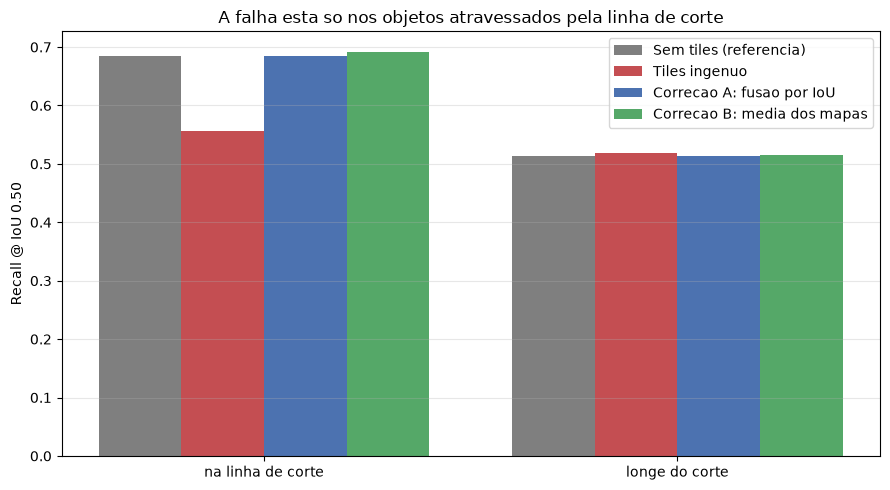

In [14]:
groups = {"na linha de corte": [], "longe do corte": []}
recall = {m: {g: [0, 0] for g in groups} for m in METHODS}     # [casados, total]
split_counts = {m: 0 for m in METHODS}
n_on_cut_total = 0

for run, gt in zip(runs, gts):

    on_cut = objects_on_cut(gt, run["owner"])
    n_on_cut_total += int(on_cut.sum())

    for method in METHODS:

        iou = label_map_iou_matrix(run["maps"][method], gt)
        matched = np.zeros(int(gt.max()), dtype=bool)
        for _, g in greedy_match_from_iou(iou, 0.50):
            matched[g] = True

        recall[method]["na linha de corte"][0] += int((matched & on_cut).sum())
        recall[method]["na linha de corte"][1] += int(on_cut.sum())
        recall[method]["longe do corte"][0] += int((matched & ~on_cut).sum())
        recall[method]["longe do corte"][1] += int((~on_cut).sum())

        for gt_id in np.flatnonzero(on_cut) + 1:
            if len(pieces(run["maps"][method], gt, gt_id)) >= 2:
                split_counts[method] += 1

recall_df = pd.DataFrame({
    METHODS[m]: {g: recall[m][g][0] / max(recall[m][g][1], 1) for g in groups} for m in METHODS
}).T
recall_df["objetos partidos (na linha)"] = [split_counts[m] for m in METHODS]

print(f"objetos de GT: {sum(n_objects)} | na linha de corte: {n_on_cut_total} "
      f"({100 * n_on_cut_total / sum(n_objects):.1f}%)\n")
print(recall_df.rename(columns={"na linha de corte": "recall@0.50 na linha",
                                "longe do corte": "recall@0.50 longe"}))

x = np.arange(len(groups)); w = 0.2
plt.figure(figsize=(9, 5))
for k, method in enumerate(METHODS):
    plt.bar(x + (k - 1.5) * w, [recall_df.loc[METHODS[method], g] for g in groups],
            width=w, label=METHODS[method], color=METHOD_COLORS[method])
plt.xticks(x, list(groups)); plt.ylabel("Recall @ IoU 0.50")
plt.title("A falha esta so nos objetos atravessados pela linha de corte")
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## Varredura: sobreposição e limiar de fusão

Mais sobreposição = mais tiles = **mais linhas de corte** (a colagem ingênua
piora), mas também uma faixa maior em que os dois tiles se pronunciam sobre o
mesmo objeto (a fusão melhora, e a média dos mapas ganha contexto na borda).
Com sobreposição zero não há faixa nenhuma e a Correção A não tem onde medir
IoU — por isso a varredura começa em 8 px.

O limiar de fusão só afeta a Correção A e é reavaliado sem refazer nenhum
forward.

sobreposicao   8px |  25 tiles | Tiles ingenuo 0.1212 | Correcao A: fusao por IoU 0.1380 | Correcao B: media dos mapas 0.1374 | 7s
sobreposicao  16px |  25 tiles | Tiles ingenuo 0.1185 | Correcao A: fusao por IoU 0.1375 | Correcao B: media dos mapas 0.1371 | 7s
sobreposicao  32px |  25 tiles | Tiles ingenuo 0.1177 | Correcao A: fusao por IoU 0.1383 | Correcao B: media dos mapas 0.1378 | 7s
sobreposicao  64px |  49 tiles | Tiles ingenuo 0.1162 | Correcao A: fusao por IoU 0.1485 | Correcao B: media dos mapas 0.1457 | 12s
sobreposicao  96px | 169 tiles | Tiles ingenuo 0.0904 | Correcao A: fusao por IoU 0.1425 | Correcao B: media dos mapas 0.1391 | 36s


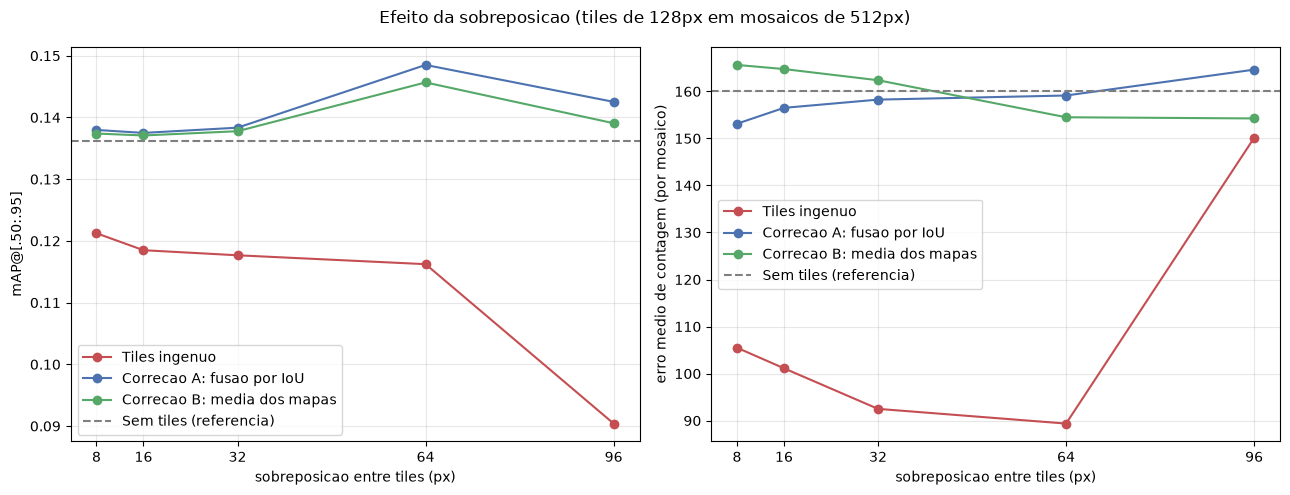

In [15]:
# ============================================================
# VARREDURA DE SOBREPOSICAO
# ============================================================

sweep_rows = []
full_cache = [r["full_outputs"] for r in runs]      # a referencia nao depende dos tiles

for overlap in OVERLAP_SWEEP:

    t0 = time.time()
    runs_ov = [run_pipelines(m["image"], TILE, overlap, FUSE_IOU, full_outputs=fo)
               for m, fo in zip(mosaics, full_cache)]
    res_ov = evaluate_runs(runs_ov, gts)

    for method in ("tiles_ingenuo", "fusao_iou", "media_mapas"):
        sweep_rows.append({
            "overlap": overlap, "n_tiles": len(runs_ov[0]["windows"]), "method": method,
            "map": res_ov[method]["mAP@[.50:.95]"], "ap50": res_ov[method]["AP@0.50"],
            "count_error": res_ov[method]["erro medio de contagem"],
        })

    print(f"sobreposicao {overlap:3d}px | {len(runs_ov[0]['windows']):3d} tiles | "
          + " | ".join(f"{METHODS[m]} {res_ov[m]['mAP@[.50:.95]']:.4f}" for m in ("tiles_ingenuo", "fusao_iou", "media_mapas"))
          + f" | {time.time() - t0:.0f}s")

sweep_df = pd.DataFrame(sweep_rows)
ref_map_value = results["referencia"]["mAP@[.50:.95]"]
ref_count = results["referencia"]["erro medio de contagem"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel, ref in [(axes[0], "map", "mAP@[.50:.95]", ref_map_value),
                                (axes[1], "count_error", "erro medio de contagem (por mosaico)", ref_count)]:
    for method in ("tiles_ingenuo", "fusao_iou", "media_mapas"):
        rows = sweep_df[sweep_df.method == method]
        ax.plot(rows.overlap, rows[metric], marker="o", label=METHODS[method], color=METHOD_COLORS[method])
    ax.axhline(ref, color=METHOD_COLORS["referencia"], linestyle="--", label=METHODS["referencia"])
    ax.set_xlabel("sobreposicao entre tiles (px)"); ax.set_ylabel(ylabel)
    ax.set_xticks(OVERLAP_SWEEP); ax.grid(alpha=0.3); ax.legend()
plt.suptitle(f"Efeito da sobreposicao (tiles de {TILE}px em mosaicos de {MOSAIC_H}px)")
plt.tight_layout(); plt.show()

In [16]:
# ============================================================
# LIMIAR DE FUSAO  (so a Correcao A; reusa os tiles ja decodificados)
# ============================================================

fuse_rows = []

for thr in FUSE_IOU_SWEEP:

    fused_runs = []
    for r in runs:
        fused, n_merges = fuse_instances(r["_tile_labels"], r["windows"], r["_offsets"], r["_naive_raw"], iou_threshold=thr)
        fused_runs.append({"maps": {"fusao_iou": fused}, "fg_prob": {"fusao_iou": r["fg_prob"]["fusao_iou"]},
                           "n_merges": n_merges})

    res = evaluate_runs(fused_runs, gts, methods=["fusao_iou"])["fusao_iou"]
    fuse_rows.append({
        "limiar IoU (faixa)": thr,
        "fusoes": int(sum(fr["n_merges"] for fr in fused_runs)),
        "mAP@[.50:.95]": res["mAP@[.50:.95]"], "AP@0.50": res["AP@0.50"],
        "FP@0.50": res["FP@0.50"], "FN@0.50": res["FN@0.50"],
        "erro medio de contagem": res["erro medio de contagem"],
    })

fuse_df = pd.DataFrame(fuse_rows).set_index("limiar IoU (faixa)")
print(f"tiles ingenuo (sem fusao): mAP {results['tiles_ingenuo']['mAP@[.50:.95]']:.4f} | "
      f"FP {results['tiles_ingenuo']['FP@0.50']} | FN {results['tiles_ingenuo']['FN@0.50']}")
fuse_df

tiles ingenuo (sem fusao): mAP 0.1177 | FP 2264 | FN 2784


,fusoes,mAP@[.50:.95],AP@0.50,FP@0.50,FN@0.50,erro medio de contagem
limiar IoU (faixa),,,,,,
0.1000,2879,0.1388,0.4149,1463,2747,160.5000
0.2500,2868,0.1388,0.4149,1464,2747,160.3750
0.5000,2820,0.1383,0.4137,1480,2746,158.2500
0.7500,2630,0.1378,0.4128,1516,2740,153.0000


In [17]:
# ============================================================
# SALVA OS NUMEROS DA PARTE 4
# ============================================================

def _clean(d):
    return {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v)
            for k, v in d.items() if not k.startswith("_")}

payload = {
    "config": {
        "tile": TILE, "overlap": OVERLAP, "fuse_iou": FUSE_IOU,
        "grid": list(GRID), "n_mosaics": N_MOSAICS, "mosaic_size": [MOSAIC_H, MOSAIC_W],
        "objetos_gt": int(sum(n_objects)), "objetos_na_linha_de_corte": int(n_on_cut_total),
        "modelo": train_config, "checkpoint": CHECKPOINT,
    },
    "metricas": {m: _clean(results[m]) for m in METHODS},
    "ap_por_limiar": {m: {f"{t:.2f}": float(v) for t, v in results[m]["_aps"].items()} for m in METHODS},
    "recall_por_grupo": {
        m: {g: float(recall[m][g][0] / max(recall[m][g][1], 1)) for g in groups} for m in METHODS
    },
    "objetos_partidos_na_linha": {m: int(split_counts[m]) for m in METHODS},
    "varredura_sobreposicao": sweep_rows,
    "varredura_limiar_fusao": fuse_rows,
}

with open(os.path.join(RESULTS_DIR, "4_inference.json"), "w") as fh:
    json.dump(payload, fh, indent=2)

print(json.dumps({k: payload[k] for k in ("metricas", "recall_por_grupo", "objetos_partidos_na_linha")}, indent=2))

{
  "metricas": {
    "referencia": {
      "IoU (semantico)": 0.560982130623464,
      "Dice (semantico)": 0.7178687357301405,
      "mAP@[.50:.95]": 0.13621907497893854,
      "AP@0.50": 0.40880762563849105,
      "AP@0.75": 0.03987505409300564,
      "AP@0.90": 0.00011941288786710465,
      "TP@0.50": 3089.0,
      "FP@0.50": 1465.0,
      "FN@0.50": 2745.0,
      "instancias previstas": 4554.0,
      "erro medio de contagem": 160.0
    },
    "tiles_ingenuo": {
      "IoU (semantico)": 0.5607911993705754,
      "Dice (semantico)": 0.7177046622447539,
      "mAP@[.50:.95]": 0.11766812386025342,
      "AP@0.50": 0.3725899510893569,
      "AP@0.75": 0.03043598319427966,
      "AP@0.90": 7.96496153435524e-05,
      "TP@0.50": 3050.0,
      "FP@0.50": 2264.0,
      "FN@0.50": 2784.0,
      "instancias previstas": 5314.0,
      "erro medio de contagem": 92.5
    },
    "fusao_iou": {
      "IoU (semantico)": 0.5607911993705754,
      "Dice (semantico)": 0.7177046622447539,
      "mAP@[.5

* **O slide 83 funciona para o que ele foi feito.** A Correção B (média
  ponderada dos mapas de classe e de distância entre tiles, um só watershed no
  mosaico) chega perto da referência sem tiles: para mapas densos, "parte interna
  + média" é exatamente a receita certa.
* **Para instâncias, a mesma receita quebra na linha de corte.** Rótulos não têm
  média. Na colagem ingênua todo núcleo atravessado por uma linha de corte vira
  dois — a tabela de recall por grupo mostra que os objetos longe do corte são
  iguais em todas as pipelines e que a queda de mAP vem inteira dos objetos na
  linha (falsos positivos de pedaços + IoU baixo em cada pedaço).
* **A correção usa a informação que a colagem joga fora.** Os dois tiles enxergam
  o mesmo núcleo na faixa de sobreposição; medir IoU **só nessa faixa** (fora dela
  apenas um dos tiles se pronuncia) e unir por union-find recupera os objetos
  partidos sem mexer em nenhum outro pixel — o que muda entre "ingênuo" e
  "Correção A" são só os ids.
* **O que a fusão não recupera:** um núcleo que um dos tiles nem detectou por
  falta de contexto na borda (marcador de watershed cortado ou abaixo de
  `MIN_MARKER_SIZE`). Isso só a Correção B resolve, porque ela decide *depois* de
  juntar o contexto dos dois tiles. Daí a Correção B ficar acima da A.
* **Por que a Correção B não é a resposta geral.** Ela depende de a representação
  ser um mapa denso comparável entre tiles. Na Trilha B (embeddings) cada tile
  aprende seu próprio espaço de embedding — não há média possível — e só a fusão
  ao nível de instância (por IoU na faixa, ou por proximidade de centros na
  Trilha C) se aplica. É por isso que o enunciado pede a fusão de instâncias.
* **Sobreposição e limiar.** Mais sobreposição piora o ingênuo (mais linhas de
  corte) e melhora as correções (faixa maior). O limiar de fusão é pouco sensível
  entre 0,25 e 0,5; baixo demais funde vizinhos encostados de verdade (FP → FN).